# 1. AE Prototype

10AWG, 24AWG 데이터를 읽고 첫 5개 정상(g) 샘플로 AE 기반 Reconstruction Error를 확인함

## 1. 데이터 읽기 및 저장

In [2]:
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 학습 파라미터
SEED = 42
LEARNING_RATE = 0.001
EPOCHS = 200
TRAIN_G_COUNT = 5

random.seed(SEED)
np.random.seed(SEED)

# 데이터 경로
DATA_DIR = Path.cwd() / "data"
force_cols = [f"data{i}" for i in range(1, 201)]

# 사용할 CSV 파일
csv_files = ["10AWG.csv", "24AWG.csv"]

# CSV를 읽어서 저장
datasets = {}
for file_name in csv_files:
    csv_path = DATA_DIR / file_name
    name = csv_path.stem
    datasets[name] = pd.read_csv(csv_path)
    print(f"{name}: {datasets[name].shape}")

10AWG: (199, 201)
24AWG: (199, 201)


## 2. 첫 5개 g 샘플 선택

In [3]:
# 첫 5개 g 샘플을 학습 데이터로 사용함
train_data = {}

for name, df in datasets.items():
    g_df = df[df["Results"] == "g"]
    base_g = g_df.head(TRAIN_G_COUNT)
    train_data[name] = base_g[force_cols].copy()

    print(f"[{name}] 학습 데이터: {train_data[name].shape}")

[10AWG] 학습 데이터: (5, 200)
[24AWG] 학습 데이터: (5, 200)


## 3. AE 모델 학습

In [4]:
# 200 -> 32 -> 16 -> 32 -> 200 AE 모델 생성함
def build_autoencoder():
    return MLPRegressor(
        hidden_layer_sizes=(32, 16, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=LEARNING_RATE,
        max_iter=EPOCHS,
        random_state=SEED,
        early_stopping=False,
    )

In [5]:
# 파일별로 첫 5개 g 데이터로 AE 학습함
models_by_file = {}
imputers = {}
scalers = {}

for name, x_train_df in train_data.items():
    x_train = x_train_df.apply(pd.to_numeric, errors="coerce")

    # 학습 정상 데이터 기준으로 표준화함
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)

    model = build_autoencoder()
    model.fit(x_train_scaled, x_train_scaled)

    models_by_file[name] = model
    scalers[name] = scaler

    print(f"[{name}] AE 학습 완료")
    print(f"학습률: {LEARNING_RATE}")
    print(f"Epoch: {EPOCHS}")
    print(f"반복 횟수: {model.n_iter_}")
    print(f"마지막 loss: {model.loss_:.6f}")

[10AWG] AE 학습 완료
학습률: 0.001
Epoch: 200
반복 횟수: 143
마지막 loss: 0.002322
[24AWG] AE 학습 완료
학습률: 0.001
Epoch: 200
반복 횟수: 158
마지막 loss: 0.002139


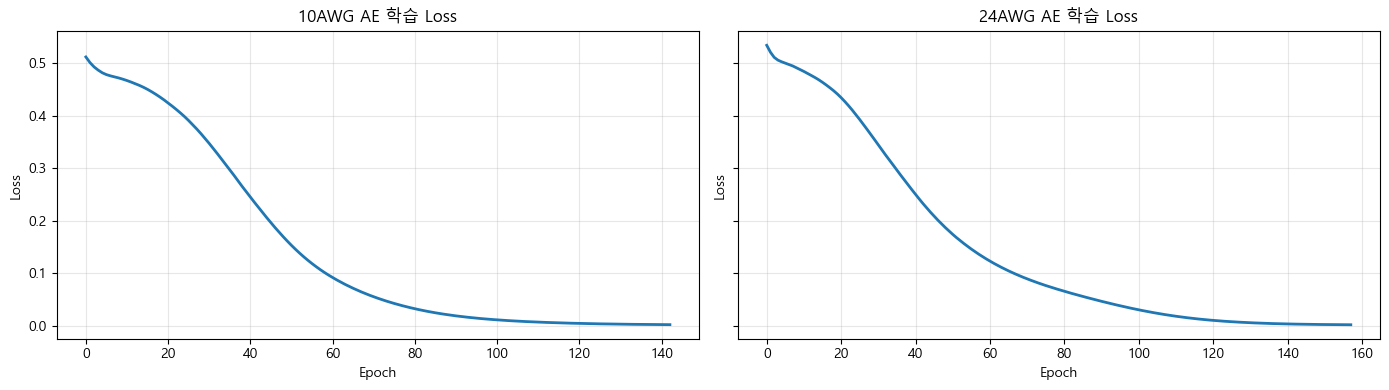

In [6]:
# 학습 loss 확인
fig, axes = plt.subplots(1, len(models_by_file), figsize=(7 * len(models_by_file), 4), sharey=True)

if len(models_by_file) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models_by_file.items()):
    ax.plot(model.loss_curve_, color="#1f77b4", linewidth=2)
    ax.set_title(f"{name} AE Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Reconstruction Error 계산

In [7]:
# 전체 포인트 평균 RE를 최종 RE로 사용함
error_tables = {}

for name, df in datasets.items():
    x_all = df[force_cols].apply(pd.to_numeric, errors="coerce")

    x_scaled = scalers[name].transform(x_all)
    x_pred_scaled = models_by_file[name].predict(x_scaled)

    # 포인트별 RE
    point_re = (x_scaled - x_pred_scaled) ** 2

    # 전체 평균 RE
    final_re = point_re.mean(axis=1)

    error_df = pd.DataFrame({
        "sample_index": df.index,
        "reconstruction_error": final_re,
        "Results": df["Results"].values,
    })

    error_tables[name] = error_df

    print(f"[{name}] Reconstruction Error Calculation Complete")
    display(error_df.head())

[10AWG] Reconstruction Error 계산 완료


,sample_index,reconstruction_error,Results
0,0,0.001851,g
1,1,0.000552,g
2,2,0.001197,g
3,3,0.000067,g
4,4,0.003363,g


[24AWG] Reconstruction Error 계산 완료


,sample_index,reconstruction_error,Results
0,0,0.000178,g
1,1,0.000166,g
2,2,0.001391,g
3,3,0.000265,g
4,4,0.003144,g


## 5. Reconstruction Error Plot

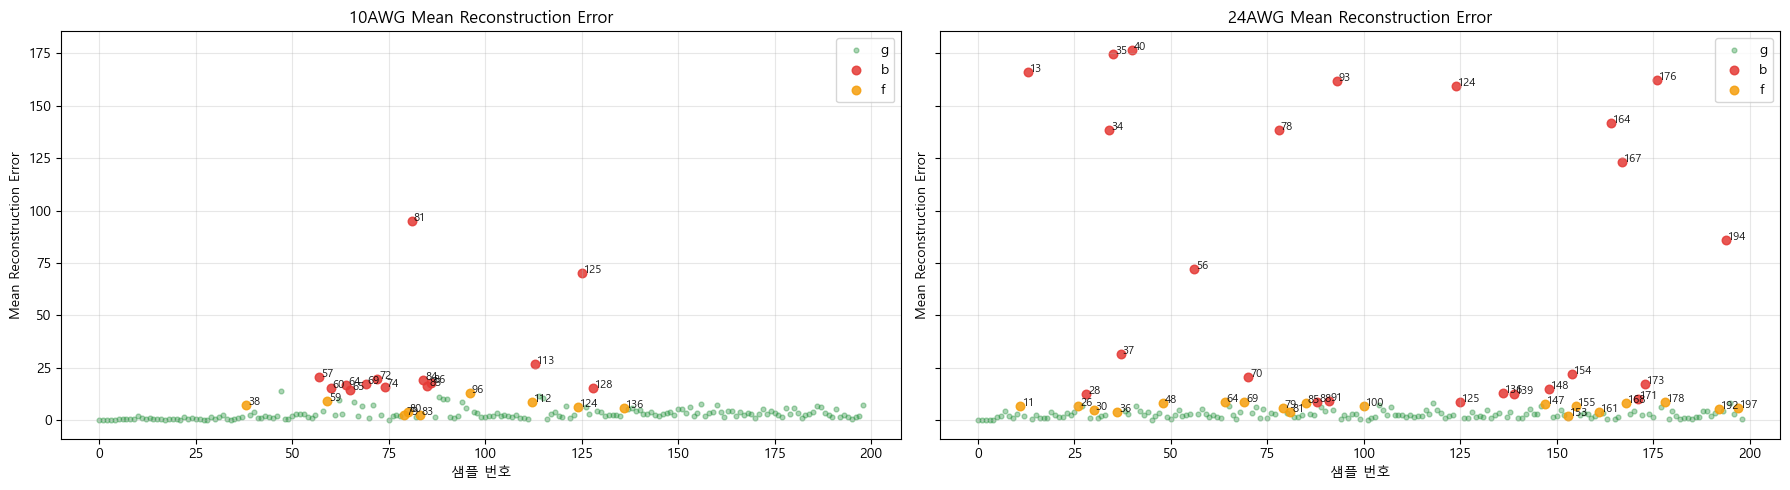

In [8]:
# g는 초록, b는 빨강, f는 주황으로 표시함
fig, axes = plt.subplots(1, len(error_tables), figsize=(9 * len(error_tables), 5), sharey=True)

if len(error_tables) == 1:
    axes = [axes]

for ax, (name, error_df) in zip(axes, error_tables.items()):
    for label, color in [("g", "#168a2f"), ("b", "#e53935"), ("f", "#f59e0b")]:
        label_df = error_df[error_df["Results"] == label]

        ax.scatter(
            label_df["sample_index"],
            label_df["reconstruction_error"],
            color=color,
            alpha=0.85 if label in ["b", "f"] else 0.35,
            s=38 if label in ["b", "f"] else 12,
            label=label,
        )

    # b, f 샘플 번호만 표시함
    bf_df = error_df[error_df["Results"].isin(["b", "f"])]
    for _, row in bf_df.iterrows():
        ax.text(
            row["sample_index"] + 0.5,
            row["reconstruction_error"],
            str(int(row["sample_index"])),
            fontsize=8,
            alpha=0.9,
        )

    ax.set_title(f"{name} Mean Reconstruction Error")
    ax.set_xlabel("샘플 번호")
    ax.set_ylabel("Mean Reconstruction Error")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()